# Data Comparison Notebook

## Purpose
This notebook compares the distributions of all variables across the processed datasets (Triagegeist, NHAMCS, and future sources like MIMIC-IV-ED). The goal is to identify distribution shifts, verify data quality, and ensure that external datasets are compatible with the Triagegeist schema before merging them for training.

---
# Section 0 - Setup and Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# =============================================================
# DATASET REGISTRY - add new datasets here, one line each.
# The entire notebook adapts automatically.
# =============================================================
DATASET_PATHS = {
    "Triagegeist": "dataset/processed/triagegeist_clean.csv",
    "NHAMCS":      "dataset/processed/nhamcs_clean.csv",
    # "MIMIC":     "dataset/processed/mimic_clean.csv", 
}

# Columns to exclude from comparison (IDs, metadata, free text)
EXCLUDE_COLS = ['patient_id', 'data_source', 'site_id', 'triage_nurse_id', 'chief_complaint_raw']

# Color palette - one color per dataset, consistent across all plots
PALETTE = {'Triagegeist': '#2196F3', 'NHAMCS': '#FF9800', 'MIMIC': '#4CAF50'}

# =============================================================
# Load all datasets
# =============================================================
datasets = {}
for name, path in DATASET_PATHS.items():
    try:
        df = pd.read_csv(path)
        datasets[name] = df
        print(f"Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    except FileNotFoundError:
        print(f"WARNING: {path} not found - skipping {name}")

active_palette = {k: PALETTE[k] for k in datasets.keys()}
dataset_names = list(datasets.keys())
print(f"\nActive datasets: {dataset_names}")

Loaded Triagegeist: 80,000 rows x 66 columns
Loaded NHAMCS: 58,124 rows x 66 columns

Active datasets: ['Triagegeist', 'NHAMCS']


---
# Section 1 - Overview and NaN Analysis

Compare shapes, column availability, and missing data patterns across all datasets.

In [2]:
# === Shape comparison ===
print("=" * 60)
print("DATASET SHAPES")
print("=" * 60)
for name, df in datasets.items():
    print(f"  {name:15s}: {df.shape[0]:>7,} rows x {df.shape[1]:>3} columns")

DATASET SHAPES
  Triagegeist    :  80,000 rows x  66 columns
  NHAMCS         :  58,124 rows x  66 columns


In [3]:
# === NaN percentage table ===
# Build a DataFrame where rows = columns, columns = datasets, values = NaN %
all_cols = [c for c in datasets[dataset_names[0]].columns if c not in EXCLUDE_COLS]

nan_table = pd.DataFrame(index=all_cols)
for name, df in datasets.items():
    nan_pct = (df[all_cols].isna().mean() * 100).round(1)
    nan_table[name] = nan_pct

# Sort by max NaN across datasets (most problematic columns first)
nan_table['max_nan'] = nan_table.max(axis=1)
nan_table = nan_table.sort_values('max_nan', ascending=False)
nan_table = nan_table.drop(columns='max_nan')

print("=" * 60)
print("NaN PERCENTAGE PER COLUMN PER DATASET")
print("=" * 60)
print(nan_table.to_string())

NaN PERCENTAGE PER COLUMN PER DATASET
                                Triagegeist  NHAMCS
hx_peripheral_vascular_disease          0.0   100.0
mental_status_triage                    0.0   100.0
num_prior_admissions_12m                0.0   100.0
num_prior_ed_visits_12m                 0.0   100.0
hx_anxiety                              0.0   100.0
hx_epilepsy                             0.0   100.0
hx_hypothyroidism                       0.0   100.0
hx_hyperthyroidism                      0.0   100.0
bmi                                     0.0   100.0
height_cm                               0.0   100.0
weight_kg                               0.0   100.0
gcs_total                               0.0   100.0
hx_atrial_fibrillation                  0.0   100.0
hx_liver_disease                        0.0   100.0
hx_pregnant                             0.0   100.0
arrival_season                          0.0   100.0
shift                                   0.0   100.0
hx_immunosuppressed       

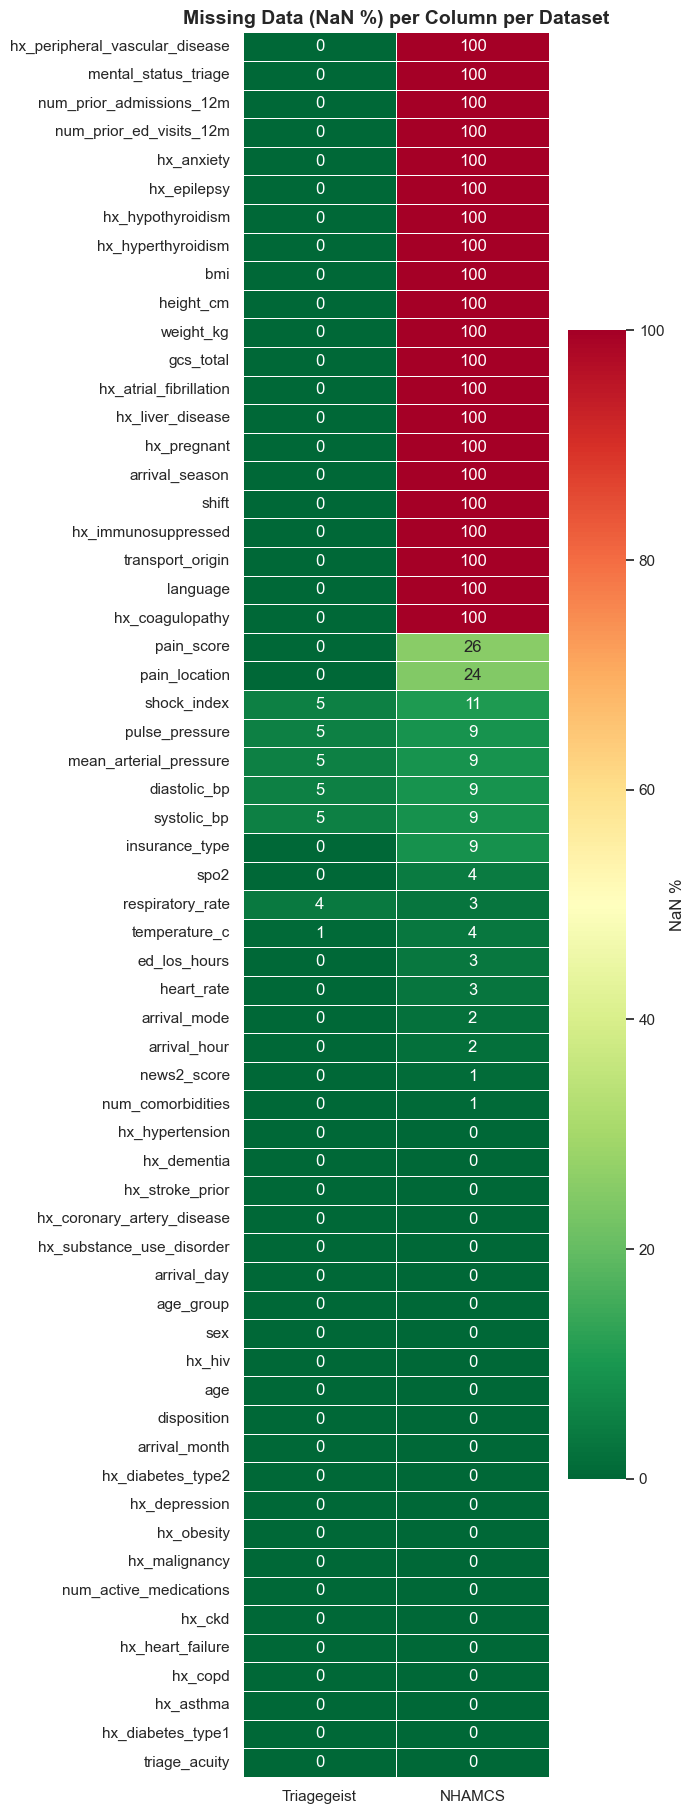

In [4]:
# === NaN heatmap ===
fig, ax = plt.subplots(figsize=(4 + len(datasets) * 1.5, max(10, len(all_cols) * 0.3)))
sns.heatmap(
    nan_table,
    annot=True, fmt='.0f', cmap='RdYlGn_r',
    vmin=0, vmax=100,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'NaN %'}
)
ax.set_title('Missing Data (NaN %) per Column per Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
# Section 2 - Target Variable: `triage_acuity`

This is the most important variable - the one we are predicting. We need to verify that the ESI level distributions are reasonably compatible across datasets.

TRIAGE ACUITY DISTRIBUTION (%)
           Triagegeist  NHAMCS
ESI Level                     
1                  4.0     1.5
2                 16.8    14.8
3                 36.2    50.9
4                 28.8    28.8
5                 14.2     4.1


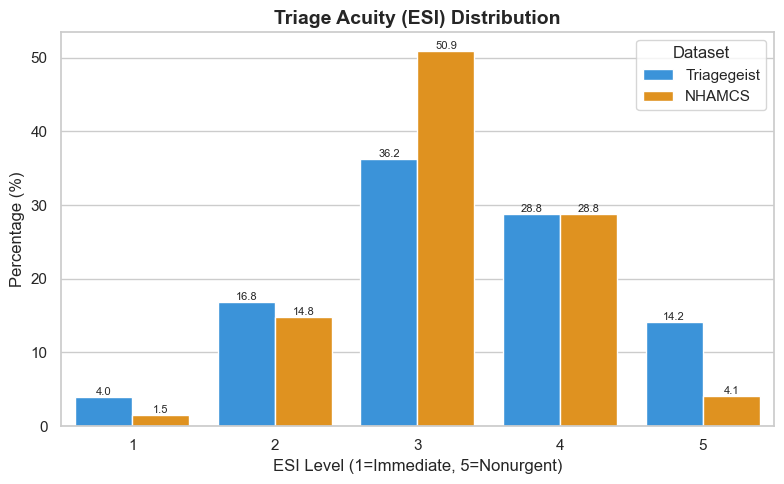

In [5]:
target = 'triage_acuity'

# === Percentage table ===
print("=" * 60)
print("TRIAGE ACUITY DISTRIBUTION (%)")
print("=" * 60)
acuity_pcts = pd.DataFrame()
for name, df in datasets.items():
    pct = (df[target].value_counts(normalize=True).sort_index() * 100).round(1)
    acuity_pcts[name] = pct
acuity_pcts.index.name = 'ESI Level'
print(acuity_pcts.to_string())

# === Bar chart ===
acuity_pcts_melted = acuity_pcts.reset_index().melt(id_vars='ESI Level', var_name='Dataset', value_name='Percentage')

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=acuity_pcts_melted, x='ESI Level', y='Percentage', hue='Dataset',
            palette=active_palette, ax=ax)
ax.set_title('Triage Acuity (ESI) Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('ESI Level (1=Immediate, 5=Nonurgent)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8)
ax.legend(title='Dataset')
plt.tight_layout()
plt.show()

---
# Section 3 - Categorical Features

For each categorical feature, we compare the frequency distributions across datasets using normalized bar charts and a Chi-squared test of independence.

In [6]:
# Identify categorical columns (excluding target, IDs, and cols that are all NaN in all datasets)
categorical_cols = [
    'sex', 'age_group', 'arrival_mode', 'arrival_day',
    'insurance_type', 'disposition', 'pain_location',
    'arrival_season', 'shift', 'mental_status_triage'
]
# Keep only columns that have data in at least one dataset
categorical_cols = [
    c for c in categorical_cols
    if any(datasets[n][c].notna().any() for n in dataset_names if c in datasets[n].columns)
]
print(f"Categorical columns to compare: {categorical_cols}")

Categorical columns to compare: ['sex', 'age_group', 'arrival_mode', 'arrival_day', 'insurance_type', 'disposition', 'pain_location', 'arrival_season', 'shift', 'mental_status_triage']


In [7]:
# === Chi-squared test summary ===
print("=" * 70)
print("CHI-SQUARED TEST RESULTS (categorical features)")
print("=" * 70)

chi2_results = []
for col in categorical_cols:
    # Build combined frequency table for all dataset pairs
    for d1, d2 in combinations(dataset_names, 2):
        s1 = datasets[d1][col].dropna()
        s2 = datasets[d2][col].dropna()
        if len(s1) == 0 or len(s2) == 0:
            continue
        combined = pd.DataFrame({'val': pd.concat([s1, s2]),
                                 'src': [d1]*len(s1) + [d2]*len(s2)})
        ct = pd.crosstab(combined['val'], combined['src'])
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            continue
        chi2, p_val, dof, _ = chi2_contingency(ct)
        chi2_results.append({
            'Feature': col,
            'Comparison': f"{d1} vs {d2}",
            'Chi2': round(chi2, 1),
            'p-value': f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.4f}",
            'Significant': 'Yes' if p_val < 0.05 else 'No'
        })

if chi2_results:
    df_chi2 = pd.DataFrame(chi2_results)
    print(df_chi2.to_string(index=False))
else:
    print("No valid comparisons found.")

CHI-SQUARED TEST RESULTS (categorical features)
       Feature            Comparison    Chi2  p-value Significant
           sex Triagegeist vs NHAMCS  1463.3 0.00e+00         Yes
     age_group Triagegeist vs NHAMCS 35181.9 0.00e+00         Yes
  arrival_mode Triagegeist vs NHAMCS 20008.9 0.00e+00         Yes
   arrival_day Triagegeist vs NHAMCS   148.0 2.04e-29         Yes
insurance_type Triagegeist vs NHAMCS 17083.5 0.00e+00         Yes
   disposition Triagegeist vs NHAMCS 14970.7 0.00e+00         Yes
 pain_location Triagegeist vs NHAMCS 54271.1 0.00e+00         Yes


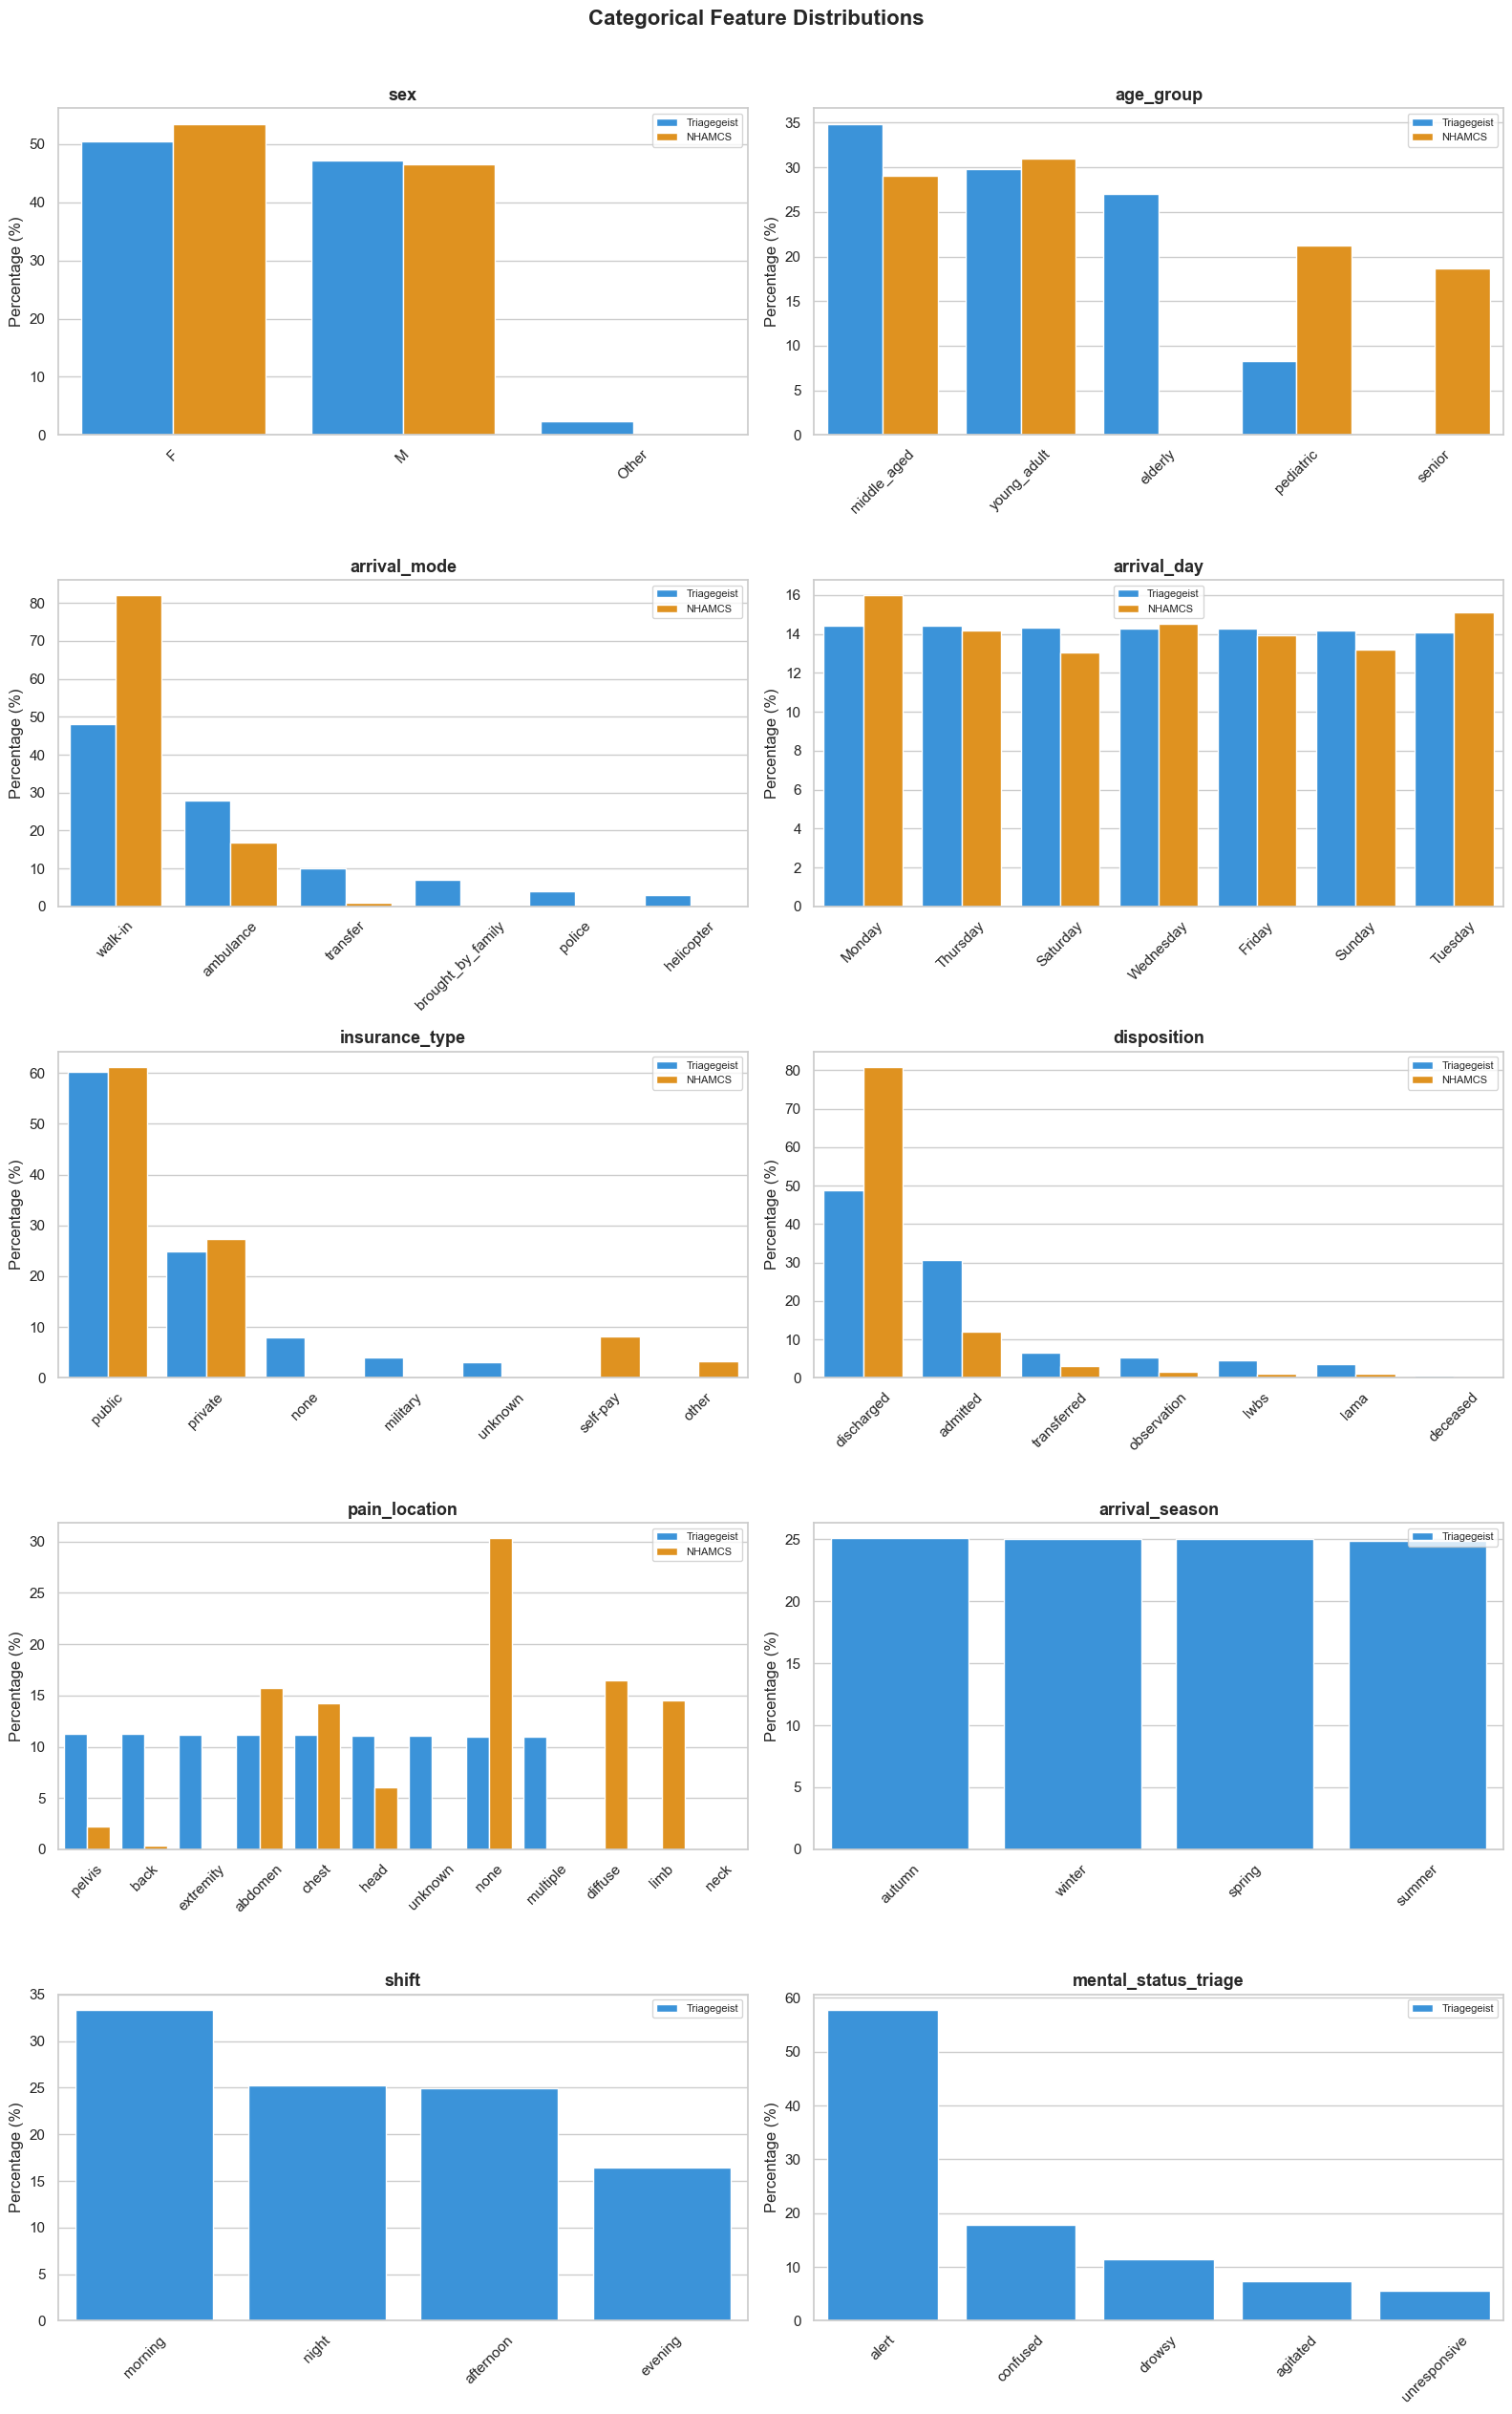

In [8]:
# === Bar charts for each categorical variable ===
n_cols = 2
n_rows = int(np.ceil(len(categorical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]

    # Build normalized percentages for each dataset
    plot_data = []
    for name, df in datasets.items():
        series = df[col].dropna()
        if len(series) == 0:
            continue
        pct = (series.value_counts(normalize=True) * 100).reset_index()
        pct.columns = ['Category', 'Percentage']
        pct['Dataset'] = name
        plot_data.append(pct)

    if not plot_data:
        ax.set_title(f"{col} (no data)", fontsize=12)
        ax.axis('off')
        continue

    plot_df = pd.concat(plot_data, ignore_index=True)

    sns.barplot(data=plot_df, x='Category', y='Percentage', hue='Dataset',
                palette=active_palette, ax=ax)
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

# Remove empty subplots
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
# Section 4 - Continuous Vital Signs

For continuous variables (vital signs), we use KDE plots to compare the full distribution shapes, and Kolmogorov-Smirnov tests to quantify the difference.

In [9]:
continuous_vitals = [
    'heart_rate', 'systolic_bp', 'diastolic_bp',
    'respiratory_rate', 'temperature_c', 'spo2',
    'mean_arterial_pressure', 'pulse_pressure',
    'shock_index', 'pain_score'
]
# Keep only columns with data in at least one dataset
continuous_vitals = [
    c for c in continuous_vitals
    if any(datasets[n][c].notna().any() for n in dataset_names if c in datasets[n].columns)
]
print(f"Continuous vital sign columns to compare: {continuous_vitals}")

Continuous vital sign columns to compare: ['heart_rate', 'systolic_bp', 'diastolic_bp', 'respiratory_rate', 'temperature_c', 'spo2', 'mean_arterial_pressure', 'pulse_pressure', 'shock_index', 'pain_score']


In [10]:
# === Summary statistics table ===
print("=" * 80)
print("VITAL SIGNS SUMMARY STATISTICS")
print("=" * 80)

stats_rows = []
for col in continuous_vitals:
    for name, df in datasets.items():
        vals = df[col].dropna()
        if len(vals) == 0:
            continue
        stats_rows.append({
            'Feature': col,
            'Dataset': name,
            'Count': len(vals),
            'Mean': round(vals.mean(), 1),
            'Std': round(vals.std(), 1),
            'Min': round(vals.min(), 1),
            'Median': round(vals.median(), 1),
            'Max': round(vals.max(), 1),
        })

df_stats = pd.DataFrame(stats_rows)
print(df_stats.to_string(index=False))

VITAL SIGNS SUMMARY STATISTICS
               Feature     Dataset  Count  Mean  Std   Min  Median   Max
            heart_rate Triagegeist  80000  91.9 19.5  30.0    89.6 207.7
            heart_rate      NHAMCS  56347  91.9 22.7  20.0    88.0 232.0
           systolic_bp Triagegeist  75854 121.6 24.2  40.0   123.1 226.9
           systolic_bp      NHAMCS  52970 134.9 24.4  43.0   132.0 289.0
          diastolic_bp Triagegeist  75854  74.5 14.3  20.0    75.3 134.8
          diastolic_bp      NHAMCS  52898  79.1 14.9  21.0    78.0 190.0
      respiratory_rate Triagegeist  76933  18.3  4.6   8.0    17.3  51.5
      respiratory_rate      NHAMCS  56325  19.3  4.7   4.0    18.0  60.0
         temperature_c Triagegeist  79426  37.6  0.9  35.1    37.5  41.8
         temperature_c      NHAMCS  56079  36.8  0.6  28.9    36.8  43.3
                  spo2 Triagegeist  80000  95.8  4.3  60.4    97.0 100.0
                  spo2      NHAMCS  55769  97.7  3.0  52.0    98.0 100.0
mean_arterial_pressu

In [11]:
# === Kolmogorov-Smirnov test ===
print("=" * 70)
print("KOLMOGOROV-SMIRNOV TEST RESULTS (continuous features)")
print("=" * 70)

ks_results = []
for col in continuous_vitals:
    for d1, d2 in combinations(dataset_names, 2):
        v1 = datasets[d1][col].dropna()
        v2 = datasets[d2][col].dropna()
        if len(v1) == 0 or len(v2) == 0:
            continue
        ks_stat, p_val = ks_2samp(v1, v2)
        mean_diff_pct = abs(v1.mean() - v2.mean()) / (v1.mean() + 1e-9) * 100
        ks_results.append({
            'Feature': col,
            'Comparison': f"{d1} vs {d2}",
            'KS Stat': round(ks_stat, 3),
            'p-value': f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.4f}",
            'Mean Diff %': round(mean_diff_pct, 1),
            'Significant': 'Yes' if p_val < 0.05 else 'No'
        })

if ks_results:
    df_ks = pd.DataFrame(ks_results)
    print(df_ks.to_string(index=False))
else:
    print("No valid comparisons found.")

KOLMOGOROV-SMIRNOV TEST RESULTS (continuous features)
               Feature            Comparison  KS Stat   p-value  Mean Diff % Significant
            heart_rate Triagegeist vs NHAMCS    0.045  2.81e-59          0.1         Yes
           systolic_bp Triagegeist vs NHAMCS    0.174  0.00e+00         10.9         Yes
          diastolic_bp Triagegeist vs NHAMCS    0.105 1.12e-300          6.2         Yes
      respiratory_rate Triagegeist vs NHAMCS    0.291  0.00e+00          5.1         Yes
         temperature_c Triagegeist vs NHAMCS    0.516  0.00e+00          2.1         Yes
                  spo2 Triagegeist vs NHAMCS    0.278  0.00e+00          1.9         Yes
mean_arterial_pressure Triagegeist vs NHAMCS    0.171  0.00e+00          8.3         Yes
        pulse_pressure Triagegeist vs NHAMCS    0.214  0.00e+00         18.4         Yes
           shock_index Triagegeist vs NHAMCS    0.153  0.00e+00         15.3         Yes
            pain_score Triagegeist vs NHAMCS    0.164  0

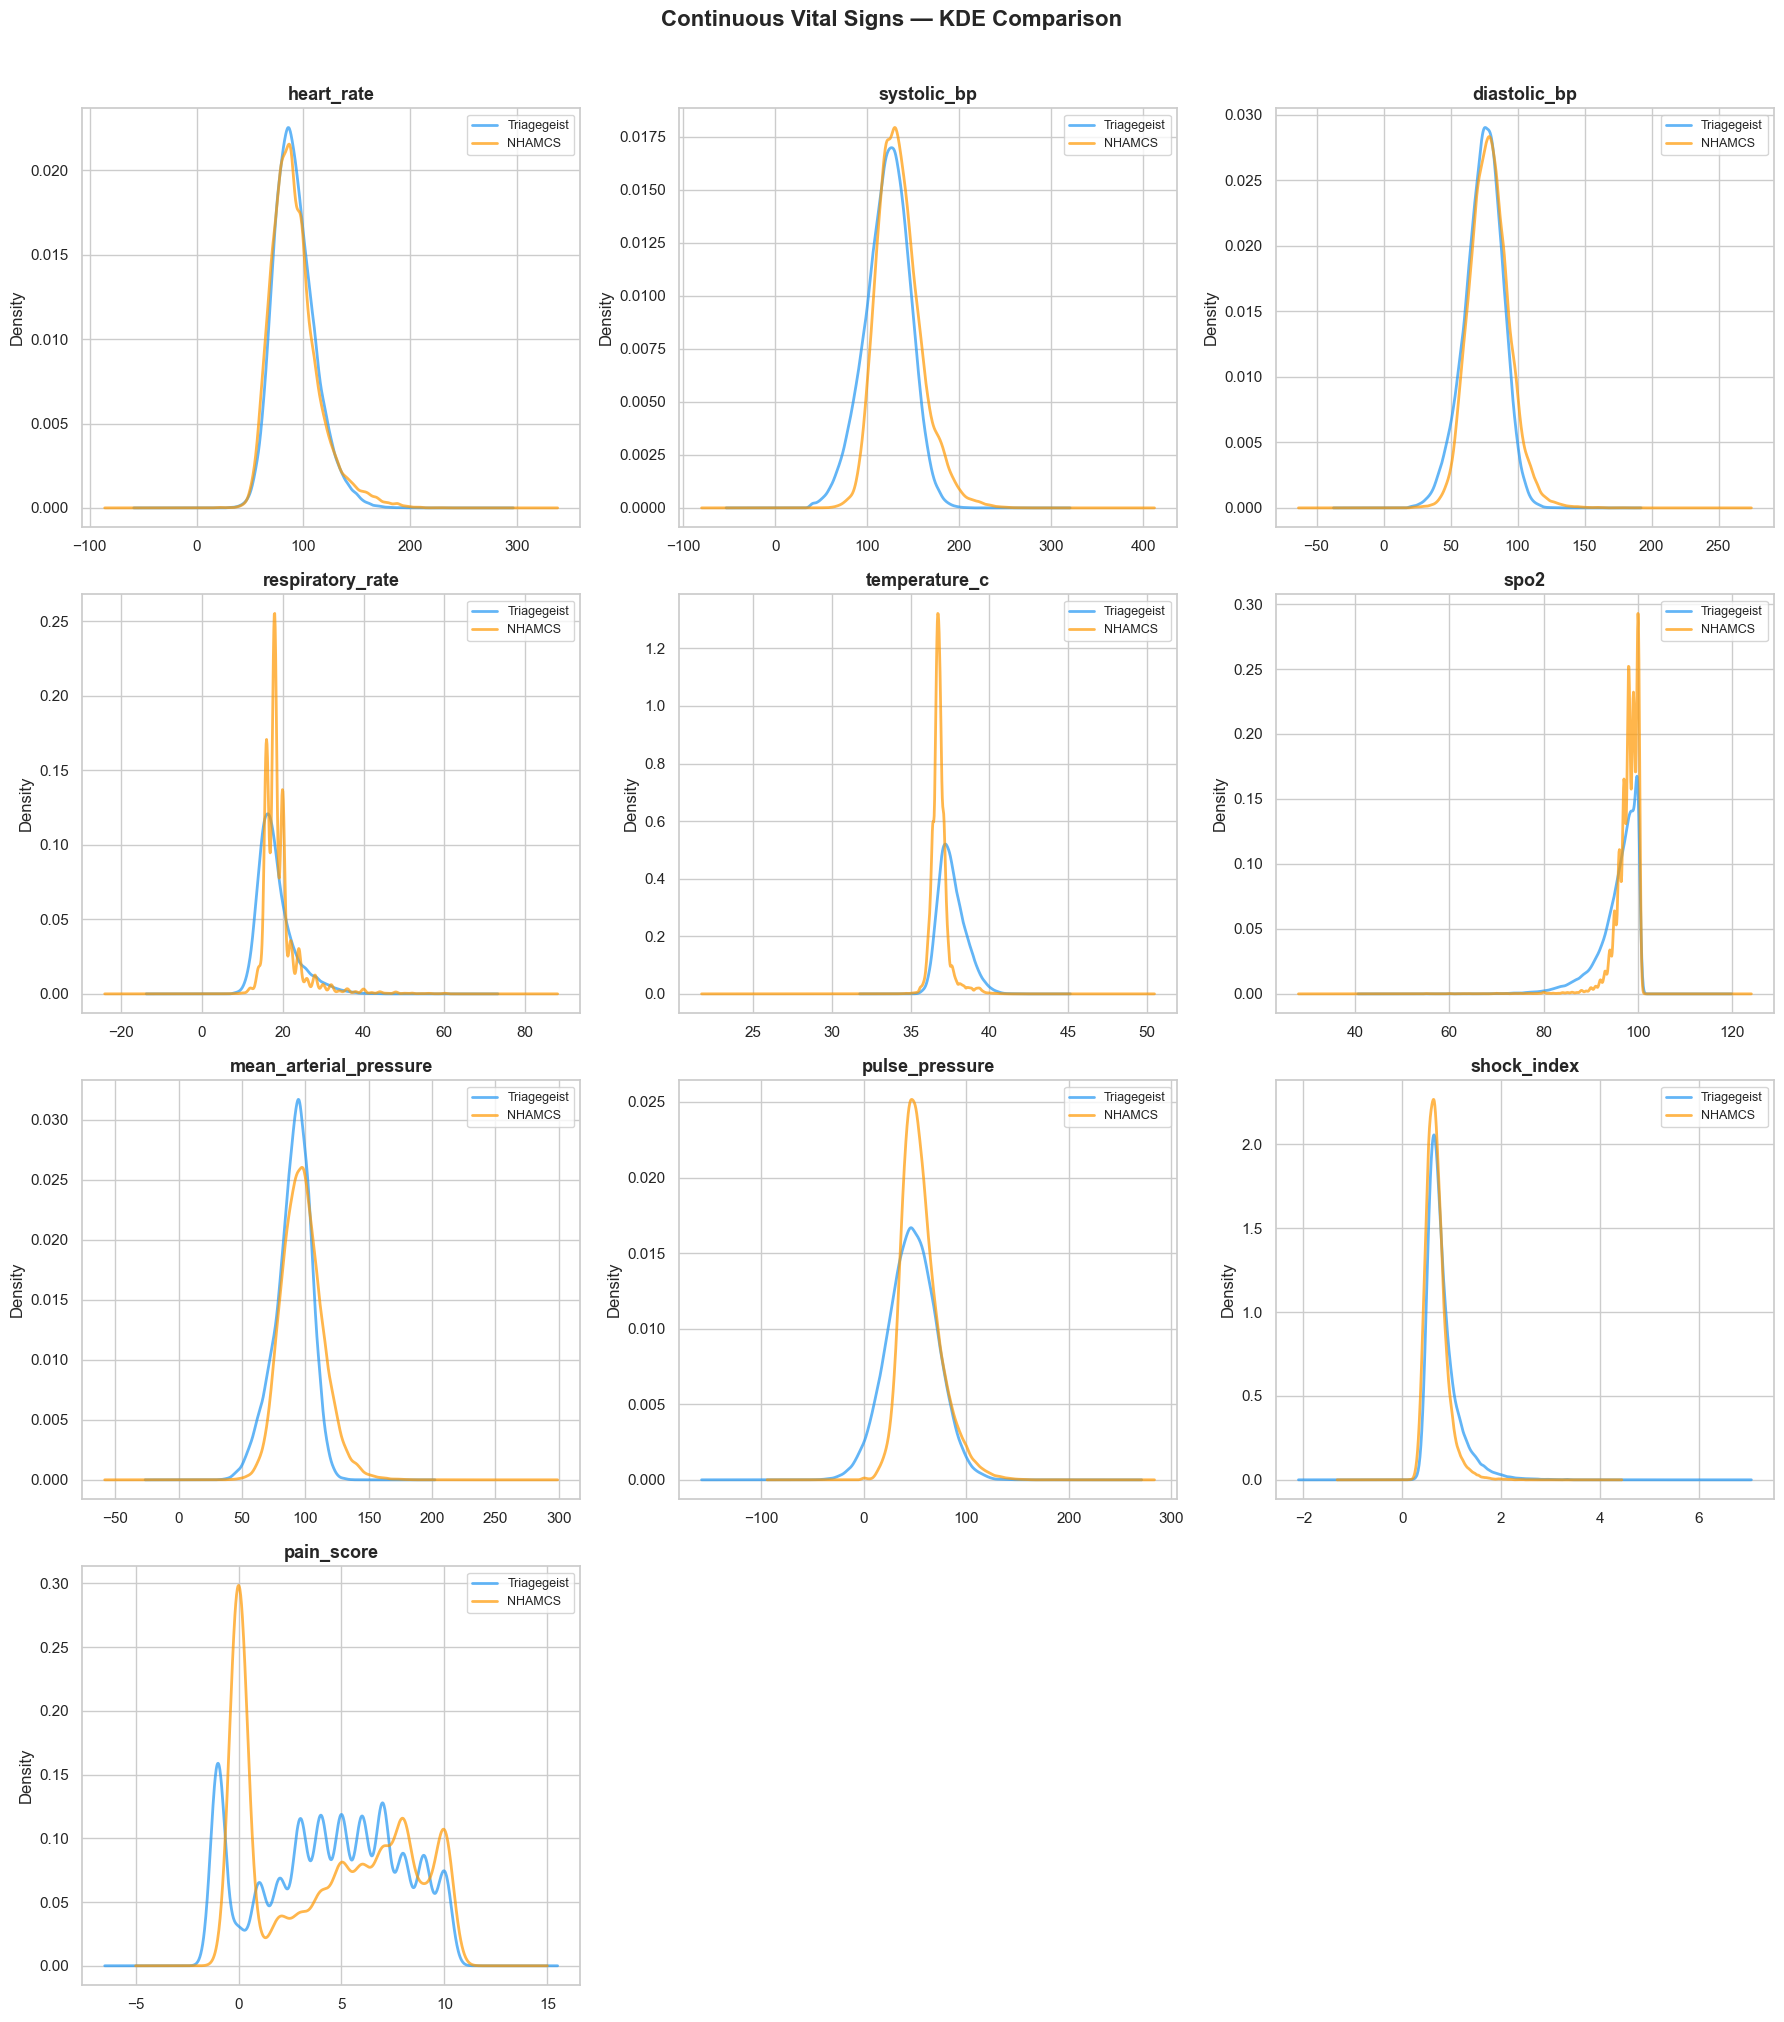

In [12]:
# === KDE plots ===
n_cols_plot = 3
n_rows_plot = int(np.ceil(len(continuous_vitals) / n_cols_plot))
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 5 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(continuous_vitals):
    ax = axes[i]
    for name, df in datasets.items():
        vals = df[col].dropna()
        if len(vals) > 0:
            vals.plot.kde(ax=ax, label=name, color=active_palette[name], alpha=0.7, linewidth=2)
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_ylabel('Density')
    ax.set_xlabel('')
    ax.legend(fontsize=9)

for j in range(len(continuous_vitals), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Continuous Vital Signs - KDE Comparison', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
# Section 5 - Discrete Numerical Features

Variables like `age`, `news2_score`, `num_comorbidities`, and `num_active_medications` are integers with limited ranges. Histograms with aligned bins are more appropriate than KDE for these.

In [13]:
discrete_cols = [
    'age', 'news2_score', 'num_comorbidities', 'num_active_medications',
    'arrival_hour', 'arrival_month', 'ed_los_hours'
]
discrete_cols = [
    c for c in discrete_cols
    if any(datasets[n][c].notna().any() for n in dataset_names if c in datasets[n].columns)
]
print(f"Discrete numerical columns to compare: {discrete_cols}")

Discrete numerical columns to compare: ['age', 'news2_score', 'num_comorbidities', 'num_active_medications', 'arrival_hour', 'arrival_month', 'ed_los_hours']


In [14]:
# === Summary statistics ===
print("=" * 80)
print("DISCRETE NUMERICAL FEATURES - SUMMARY STATISTICS")
print("=" * 80)

stats_rows_d = []
for col in discrete_cols:
    for name, df in datasets.items():
        vals = df[col].dropna()
        if len(vals) == 0:
            continue
        stats_rows_d.append({
            'Feature': col,
            'Dataset': name,
            'Count': len(vals),
            'Mean': round(vals.mean(), 1),
            'Std': round(vals.std(), 1),
            'Min': round(vals.min(), 1),
            'Median': round(vals.median(), 1),
            'Max': round(vals.max(), 1),
        })

df_stats_d = pd.DataFrame(stats_rows_d)
print(df_stats_d.to_string(index=False))

DISCRETE NUMERICAL FEATURES - SUMMARY STATISTICS
               Feature     Dataset  Count  Mean  Std  Min  Median  Max
                   age Triagegeist  80000  48.5 24.2  1.0    48.0 94.0
                   age      NHAMCS  58124  39.7 24.6  0.0    38.0 94.0
           news2_score Triagegeist  80000   3.4  4.3  0.0     2.0 17.0
           news2_score      NHAMCS  57610   1.6  2.0  0.0     1.0 13.0
     num_comorbidities Triagegeist  80000   5.3  3.2  0.0     5.0 20.0
     num_comorbidities      NHAMCS  57717   1.3  1.8  0.0     1.0 13.0
num_active_medications Triagegeist  80000   4.8  3.9  0.0     4.0 20.0
num_active_medications      NHAMCS  58124   2.7  2.9  0.0     2.0 30.0
          arrival_hour Triagegeist  80000  11.4  6.9  0.0    11.0 23.0
          arrival_hour      NHAMCS  57113  13.4  5.9  0.0    14.0 23.0
         arrival_month Triagegeist  80000   6.5  3.5  1.0     7.0 12.0
         arrival_month      NHAMCS  58124   6.2  3.5  1.0     6.0 12.0
          ed_los_hours Triag

In [15]:
# === KS test for discrete features ===
print("=" * 70)
print("KOLMOGOROV-SMIRNOV TEST RESULTS (discrete features)")
print("=" * 70)

ks_results_d = []
for col in discrete_cols:
    for d1, d2 in combinations(dataset_names, 2):
        v1 = datasets[d1][col].dropna()
        v2 = datasets[d2][col].dropna()
        if len(v1) == 0 or len(v2) == 0:
            continue
        ks_stat, p_val = ks_2samp(v1, v2)
        mean_diff_pct = abs(v1.mean() - v2.mean()) / (v1.mean() + 1e-9) * 100
        ks_results_d.append({
            'Feature': col,
            'Comparison': f"{d1} vs {d2}",
            'KS Stat': round(ks_stat, 3),
            'p-value': f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.4f}",
            'Mean Diff %': round(mean_diff_pct, 1),
            'Significant': 'Yes' if p_val < 0.05 else 'No'
        })

if ks_results_d:
    print(pd.DataFrame(ks_results_d).to_string(index=False))

KOLMOGOROV-SMIRNOV TEST RESULTS (discrete features)
               Feature            Comparison  KS Stat  p-value  Mean Diff % Significant
                   age Triagegeist vs NHAMCS    0.142 0.00e+00         18.2         Yes
           news2_score Triagegeist vs NHAMCS    0.170 0.00e+00         54.8         Yes
     num_comorbidities Triagegeist vs NHAMCS    0.593 0.00e+00         75.1         Yes
num_active_medications Triagegeist vs NHAMCS    0.276 0.00e+00         44.0         Yes
          arrival_hour Triagegeist vs NHAMCS    0.187 0.00e+00         17.2         Yes
         arrival_month Triagegeist vs NHAMCS    0.043 1.61e-53          4.7         Yes
          ed_los_hours Triagegeist vs NHAMCS    0.047 1.27e-63         24.9         Yes


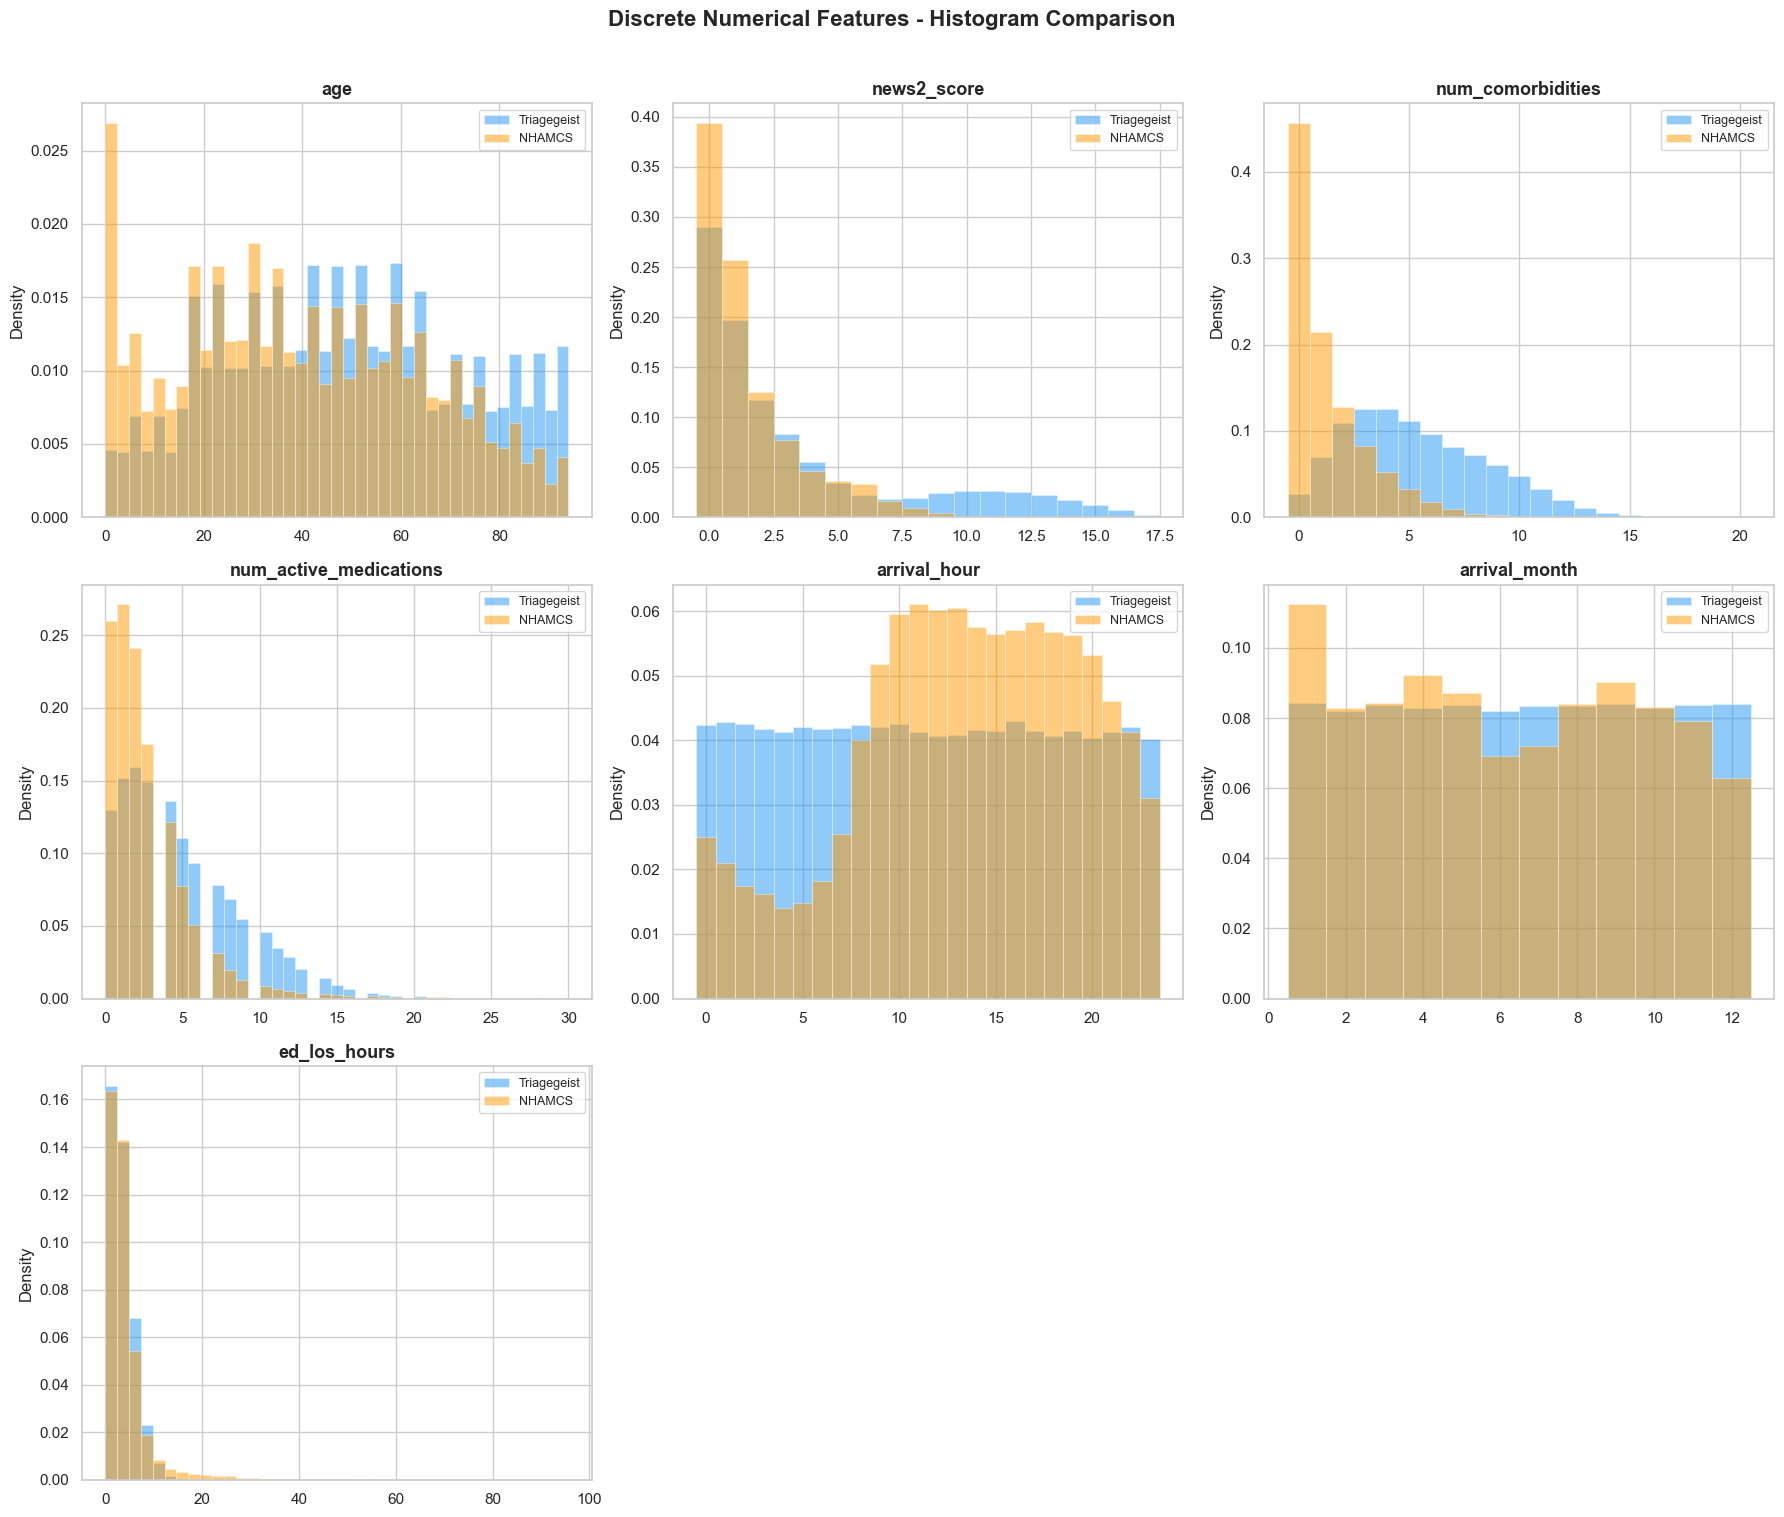

In [16]:
# === Histograms ===
n_cols_plot = 3
n_rows_plot = int(np.ceil(len(discrete_cols) / n_cols_plot))
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 5 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(discrete_cols):
    ax = axes[i]

    # Determine common bin edges across all datasets
    all_vals = pd.concat([df[col].dropna() for df in datasets.values()])
    if len(all_vals) == 0:
        ax.set_title(f"{col} (no data)"); continue

    n_unique = all_vals.nunique()
    if n_unique <= 25:
        bins = np.arange(all_vals.min() - 0.5, all_vals.max() + 1.5, 1)
    else:
        bins = np.linspace(all_vals.min(), all_vals.max(), 40)

    for name, df in datasets.items():
        vals = df[col].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=bins, density=True, alpha=0.5,
                    label=name, color=active_palette[name], edgecolor='white', linewidth=0.5)

    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

for j in range(len(discrete_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Discrete Numerical Features - Histogram Comparison', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
# Section 6 - Binary Features (Comorbidities)

All `hx_*` columns are binary (0/1). Instead of 25 separate plots, we show a single grouped bar chart comparing the **prevalence** (% of 1s) of each comorbidity across datasets. Comorbidities that are entirely NaN in a dataset are clearly marked.

In [17]:
# Identify all hx_* columns
hx_cols = [c for c in datasets[dataset_names[0]].columns if c.startswith('hx_')]
print(f"Binary comorbidity columns: {len(hx_cols)}")

Binary comorbidity columns: 25


In [18]:
# === Prevalence table ===
prevalence = pd.DataFrame(index=hx_cols)
for name, df in datasets.items():
    prev = []
    for col in hx_cols:
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(vals) == 0:
            prev.append(np.nan)
        else:
            prev.append(round(vals.mean() * 100, 1))
    prevalence[name] = prev

# Sort by Triagegeist prevalence (descending)
if 'Triagegeist' in prevalence.columns:
    prevalence = prevalence.sort_values('Triagegeist', ascending=True)

print("=" * 60)
print("COMORBIDITY PREVALENCE (% of records with condition = 1)")
print("NaN = column is entirely missing in that dataset")
print("=" * 60)
print(prevalence.sort_values('Triagegeist', ascending=False).to_string())

COMORBIDITY PREVALENCE (% of records with condition = 1)
NaN = column is entirely missing in that dataset
                                Triagegeist  NHAMCS
hx_coronary_artery_disease             28.3     7.0
hx_hypertension                        28.2    27.3
hx_atrial_fibrillation                 28.2     NaN
hx_ckd                                 28.2     3.8
hx_heart_failure                       28.1     4.2
hx_diabetes_type2                      27.9     7.4
hx_stroke_prior                        27.8     3.8
hx_immunosuppressed                    20.1     NaN
hx_hyperthyroidism                     19.9     NaN
hx_liver_disease                       19.9     NaN
hx_malignancy                          19.9     4.5
hx_anxiety                             19.9     NaN
hx_substance_use_disorder              19.9     7.6
hx_epilepsy                            19.8     NaN
hx_coagulopathy                        19.8     NaN
hx_obesity                             19.7     6.7
hx_hypothy

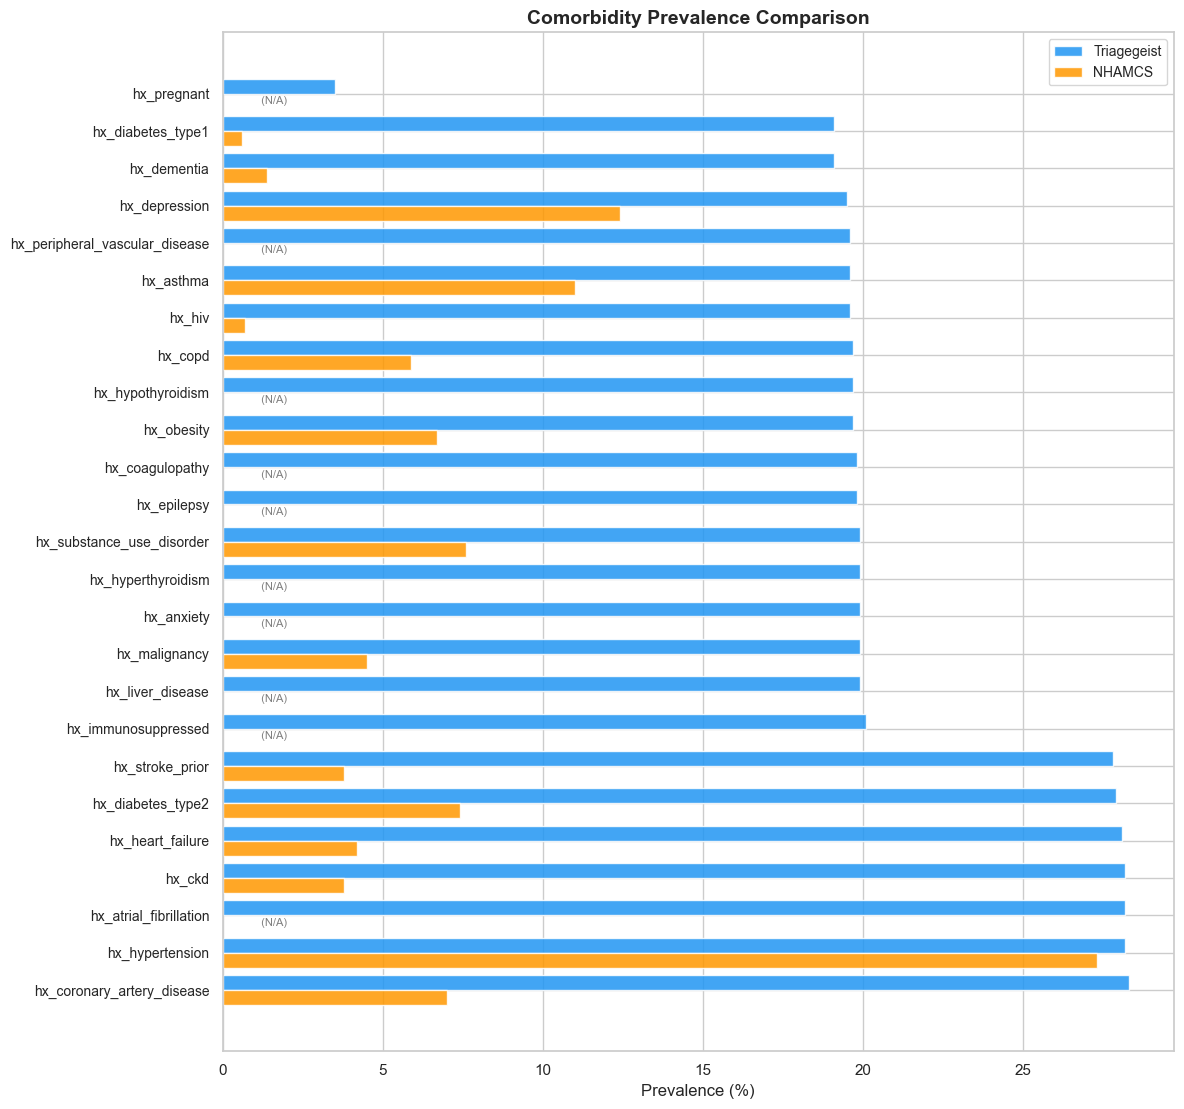

In [19]:
# === Horizontal grouped bar chart ===
fig, ax = plt.subplots(figsize=(12, max(8, len(hx_cols) * 0.45)))

y_pos = np.arange(len(hx_cols))
n_datasets = len(datasets)
bar_height = 0.8 / n_datasets

for idx, name in enumerate(dataset_names):
    if name not in prevalence.columns:
        continue
    vals = prevalence[name].values
    offset = (idx - n_datasets / 2 + 0.5) * bar_height
    bars = ax.barh(y_pos + offset, vals, height=bar_height,
                   label=name, color=active_palette[name], alpha=0.85)
    # Mark NaN columns with a cross
    for j, v in enumerate(vals):
        if pd.isna(v):
            ax.text(1, y_pos[j] + offset, '  (N/A)', va='center', fontsize=8, color='gray')

ax.set_yticks(y_pos)
ax.set_yticklabels(prevalence.index, fontsize=10)
ax.set_xlabel('Prevalence (%)', fontsize=12)
ax.set_title('Comorbidity Prevalence Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# === Chi-squared tests for binary comorbidities ===
# Only for columns that have data in at least 2 datasets
print("=" * 70)
print("CHI-SQUARED TEST RESULTS (binary comorbidities)")
print("=" * 70)

chi2_hx = []
for col in hx_cols:
    for d1, d2 in combinations(dataset_names, 2):
        s1 = pd.to_numeric(datasets[d1][col], errors='coerce').dropna()
        s2 = pd.to_numeric(datasets[d2][col], errors='coerce').dropna()
        if len(s1) < 10 or len(s2) < 10:
            continue
        combined = pd.DataFrame({'val': pd.concat([s1, s2]),
                                 'src': [d1]*len(s1) + [d2]*len(s2)})
        ct = pd.crosstab(combined['val'], combined['src'])
        if ct.shape[0] < 2:
            continue
        chi2, p_val, dof, _ = chi2_contingency(ct)
        prev1 = round(s1.mean() * 100, 1)
        prev2 = round(s2.mean() * 100, 1)
        chi2_hx.append({
            'Feature': col,
            f'Prev {d1} %': prev1,
            f'Prev {d2} %': prev2,
            'Diff (pp)': round(abs(prev1 - prev2), 1),
            'Chi2': round(chi2, 1),
            'p-value': f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.4f}",
            'Significant': 'Yes' if p_val < 0.05 else 'No'
        })

if chi2_hx:
    df_chi2_hx = pd.DataFrame(chi2_hx).sort_values('Diff (pp)', ascending=False)
    print(df_chi2_hx.to_string(index=False))
else:
    print("No comorbidities with data in multiple datasets for comparison.")

CHI-SQUARED TEST RESULTS (binary comorbidities)
                   Feature  Prev Triagegeist %  Prev NHAMCS %  Diff (pp)    Chi2   p-value Significant
                    hx_ckd                28.2            3.8       24.4 13661.1  0.00e+00         Yes
           hx_stroke_prior                27.8            3.8       24.0 13319.2  0.00e+00         Yes
          hx_heart_failure                28.1            4.2       23.9 13054.0  0.00e+00         Yes
hx_coronary_artery_disease                28.3            7.0       21.3  9714.8  0.00e+00         Yes
         hx_diabetes_type2                27.9            7.4       20.5  9136.1  0.00e+00         Yes
                    hx_hiv                19.6            0.7       18.9 11681.4  0.00e+00         Yes
         hx_diabetes_type1                19.1            0.6       18.5 11478.8  0.00e+00         Yes
               hx_dementia                19.1            1.4       17.7 10264.5  0.00e+00         Yes
             hx_malignanc

---
# Section 7 - Summary

A compact overview of all comparison results.

In [22]:
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

for name, df in datasets.items():
    non_nan_cols = [c for c in df.columns if c not in EXCLUDE_COLS and df[c].notna().any()]
    all_nan_cols = [c for c in df.columns if c not in EXCLUDE_COLS and df[c].isna().all()]
    print(f"\n--- {name} ---")
    print(f"  Records:              {len(df):,}")
    print(f"  Columns with data:    {len(non_nan_cols)}")
    print(f"  Columns all NaN:      {len(all_nan_cols)}")
    print(f"  Avg NaN per column:   {df[non_nan_cols].isna().mean().mean()*100:.1f}%")

# Count significant differences
print(f"\n--- Statistical Tests ---")
if chi2_results:
    n_sig_cat = sum(1 for r in chi2_results if r['Significant'] == 'Yes')
    print(f"  Categorical:  {n_sig_cat}/{len(chi2_results)} significant (Chi2, p<0.05)")
if ks_results:
    n_sig_ks = sum(1 for r in ks_results if r['Significant'] == 'Yes')
    print(f"  Continuous:   {n_sig_ks}/{len(ks_results)} significant (KS, p<0.05)")
if chi2_hx:
    n_sig_hx = sum(1 for r in chi2_hx if r['Significant'] == 'Yes')
    print(f"  Comorbidities: {n_sig_hx}/{len(chi2_hx)} significant (Chi2, p<0.05)")


FINAL SUMMARY

--- Triagegeist ---
  Records:              80,000
  Columns with data:    61
  Columns all NaN:      0
  Avg NaN per column:   0.5%

--- NHAMCS ---
  Records:              58,124
  Columns with data:    40
  Columns all NaN:      21
  Avg NaN per column:   3.2%

--- Statistical Tests ---
  Categorical:  7/7 significant (Chi2, p<0.05)
  Continuous:   10/10 significant (KS, p<0.05)
  Comorbidities: 15/15 significant (Chi2, p<0.05)
